# Exercise 6 - Fine-tuning a Pretrained LLM (QLoRA on TinyLlama, Fitness Domain)

---

Names: Jullian Bilan, Kyla Elijah Ramiro

CYS: BSCS 3-A AI

---

This notebook fine-tunes a pretrained Large Language Model on a domain-specific dataset using **QLoRA** (4-bit quantization + LoRA adapters), then evaluates the result with perplexity, qualitative side-by-side comparisons, and a PCA visualization of domain-word embeddings.

| Step | What we identify / build |
| --- | --- |
| 1 | **Task** — domain-specific conversational Q&A / instruction following |
| 2 | **Domain & Dataset** — fitness / training / nutrition, `its-myrto/fitness-question-answers` from Hugging Face |
| 3 | **Model** — `TinyLlama/TinyLlama-1.1B-Chat-v1.0` (instruction-tuned, fits a 4 GB RTX 3050 with 4-bit quantization) |
| 4 | **Configuration** — QLoRA (NF4 + LoRA `r=16`, `alpha=32`, target `q_proj`/`v_proj`), `SFTTrainer` from `trl` |
| 5 | **Evaluation** — perplexity on a held-out test split + qualitative base-vs-fine-tuned comparison |
| Bonus | **PCA visualization** of 30+ fitness-domain token embeddings |

## Setup

Install dependencies (skip the `%pip install` cell if your environment already has them) and configure environment variables. We force UTF-8 mode for Python on Windows so that downstream libraries (e.g. `trl`) can read their bundled Jinja chat templates without `UnicodeDecodeError`.

In [1]:
# Run once per machine; afterwards you can comment this cell out.
# Torch is installed from PyTorch's CUDA 12.8 index so it can use the RTX 3050.

%pip install --quiet --index-url https://download.pytorch.org/whl/cu128 torch
%pip install --quiet transformers datasets accelerate peft trl bitsandbytes evaluate scikit-learn matplotlib sentencepiece huggingface_hub

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ.setdefault("PYTHONUTF8", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import math
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), (
    "CUDA is not available. Install the CUDA build of PyTorch and make sure NVIDIA drivers are working."
)

DEVICE = torch.device("cuda")
print("Torch:", torch.__version__)
print("CUDA :", torch.version.cuda)
print("GPU  :", torch.cuda.get_device_name(0))
print("VRAM :", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

Torch: 2.11.0+cu128
CUDA : 12.8
GPU  : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM : 4.0 GB


## Step 1 — Identify the Task

We want a **conversational question-answering / instruction-following chatbot** for the fitness and running domain. The user asks fitness questions ("How many rest days do I need per week?", "What's a good warm-up before a 10K?") and the model should respond like a knowledgeable training buddy.

Because the input/output of the task is free-form text, the underlying ML problem is **causal language modeling on instruction–response pairs** (a.k.a. supervised fine-tuning, SFT). We therefore evaluate with **perplexity** on a held-out split (lower is better) plus qualitative side-by-side generation comparisons against the un-tuned base model.

## Step 2 — Identify the Domain & Dataset

**Domain:** fitness, exercise, training, recovery, and nutrition.

**Dataset:** [`its-myrto/fitness-question-answers`](https://huggingface.co/datasets/its-myrto/fitness-question-answers) on Hugging Face — **965 real, in-domain fitness Q&A pairs** scraped from fitness-coaching content (columns: `Question`, `Answer`). Every row is on-topic: technique tips, workout programming, recovery, nutrition, motivation, common form / injury questions, etc. We split it 700 train / 80 eval / 80 test so QLoRA fine-tuning fits comfortably in the 4 GB VRAM budget of an RTX 3050 within a few minutes.

> *Note:* we initially tried `hammamwahab/fitness-qa` (~123k rows), but it is auto-generated from generic Wikipedia and dominated by off-topic questions whose answer is the canned string *"I don't have data on that"*. Training on it collapsed the fine-tuned model into always replying with that phrase, so we switched to a curated fitness-only dataset.

We reformat each row into the **TinyLlama chat template** so the supervised fine-tune teaches the model to respond as a fitness assistant:

```
<|system|>You are a knowledgeable fitness and running coach...</s>
<|user|>{question}</s>
<|assistant|>{answer}</s>
```

In [3]:
from datasets import load_dataset

# We use `its-myrto/fitness-question-answers` (965 real fitness Q&A pairs,
# columns: `Question`, `Answer`). Earlier we tried `hammamwahab/fitness-qa`,
# but that dataset is dominated by off-topic Wikipedia questions paired with
# the canned non-answer "I don't have data on that"; training on it collapsed
# the fine-tuned model to always reply "I don't have data on that".
DATASET_NAME = "its-myrto/fitness-question-answers"

raw = load_dataset(DATASET_NAME, split="train")
print("Full dataset rows:", len(raw))
print("Columns         :", raw.column_names)
print("Example         :", raw[0])

# Normalise column names to lowercase `question` / `answer`.
raw = raw.rename_columns({"Question": "question", "Answer": "answer"})
raw = raw.remove_columns([c for c in raw.column_names if c not in ("question", "answer")])
raw = raw.shuffle(seed=SEED)


def is_clean(row):
    """Light hygiene filter — the source data is already domain-specific."""
    q = (row.get("question") or "").strip()
    a = (row.get("answer") or "").strip()
    if len(q) < 5 or len(a) < 20:
        return False
    if len(q) > 400 or len(a) > 800:
        return False
    return True


raw = raw.filter(is_clean)
print("After cleaning  :", len(raw))

# Split sizes sized to the (small) source dataset; well within the 4 GB VRAM
# budget when combined with QLoRA + grad-accum.
N_TRAIN = min(700, len(raw) - 160)
N_EVAL = 80
N_TEST = 80
needed = N_TRAIN + N_EVAL + N_TEST
assert len(raw) >= needed, f"Need >= {needed} clean rows, got {len(raw)}"

raw = raw.select(range(needed))
train_raw = raw.select(range(N_TRAIN))
eval_raw = raw.select(range(N_TRAIN, N_TRAIN + N_EVAL))
test_raw = raw.select(range(N_TRAIN + N_EVAL, N_TRAIN + N_EVAL + N_TEST))
print(f"Splits -> train={len(train_raw)} eval={len(eval_raw)} test={len(test_raw)}")
print("\n---- sample cleaned Q/A ----")
print("Q:", train_raw[0]["question"])
print("A:", train_raw[0]["answer"])

Full dataset rows: 965
Columns         : ['Unnamed: 0', 'Question', 'Answer']
Example         : {'Unnamed: 0': 0, 'Question': 'can you recommend effective core ab exercises?', 'Answer': 'sure! planks, bicycle crunches, and leg raises are great for targeting core muscles. incorporate these exercises into your routine and focus on engaging your core during other workouts too.'}


Filter:   0%|          | 0/965 [00:00<?, ? examples/s]

After cleaning  : 960
Splits -> train=700 eval=80 test=80

---- sample cleaned Q/A ----
Q: what are the best exercises for lowering blood pressure?
A: planks and wall sits.


## Step 3 — Identify the LLM

We use [`TinyLlama/TinyLlama-1.1B-Chat-v1.0`](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0):

- 1.1B parameters — small enough to run on a 4 GB RTX 3050 with 4-bit weights (~0.8 GB VRAM for the frozen model).
- Already chat / instruction-tuned, so the LoRA adapter only has to specialize the model on the fitness domain rather than teach it how to follow instructions from scratch.
- Fully open weights and supported by `transformers` + `bitsandbytes` 4-bit loading.

We load the **base model in 4-bit NF4** (the `Q` in QLoRA) and keep the original tokenizer.

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=torch.bfloat16,
)
base_model.config.use_cache = False
base_model.config.pretraining_tp = 1

print("Model loaded on:", next(base_model.parameters()).device)
print("VRAM after load: %.2f GB" % (torch.cuda.memory_allocated() / 1024**3))

W0425 20:30:29.378000 18496 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on: cuda:0
VRAM after load: 0.73 GB


In [5]:
SYSTEM_PROMPT = (
    "You are a knowledgeable fitness and running coach. "
    "Give concise, friendly, accurate answers about training, technique, recovery, and nutrition."
)

def format_example(row):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": row["question"].strip()},
        {"role": "assistant", "content": row["answer"].strip()},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

train_ds = train_raw.map(format_example, remove_columns=train_raw.column_names)
eval_ds  = eval_raw.map(format_example,  remove_columns=eval_raw.column_names)
test_ds  = test_raw.map(format_example,  remove_columns=test_raw.column_names)

print("---- formatted training example ----")
print(train_ds[0]["text"][:600], "...")

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

---- formatted training example ----
<|system|>
You are a knowledgeable fitness and running coach. Give concise, friendly, accurate answers about training, technique, recovery, and nutrition.</s>
<|user|>
what are the best exercises for lowering blood pressure?</s>
<|assistant|>
planks and wall sits.</s>
 ...


## Step 4 — Fine-tuning Configuration (QLoRA)

We freeze the 4-bit base weights and learn only small **LoRA adapters** on the attention `q_proj` and `v_proj` matrices. This is the standard QLoRA recipe.

| Hyperparameter | Value | Why |
| --- | --- | --- |
| `load_in_4bit` | `True` | Fits 1.1B params in <1 GB VRAM |
| `bnb_4bit_quant_type` | `"nf4"` | Best 4-bit format from the QLoRA paper |
| `bnb_4bit_use_double_quant` | `True` | Saves another ~0.4 bit per param |
| LoRA `r`, `alpha` | 16, 32 | Recommended starting point |
| LoRA `target_modules` | `q_proj`, `v_proj` | Touches attention without exploding parameter count |
| `lora_dropout` | 0.05 | Light regularization |
| Optimizer | `paged_adamw_8bit` | 8-bit AdamW so optimizer state fits in 4 GB |
| Precision | `bf16` | Ampere (RTX 3050) supports bf16 natively; avoids fp16 GradScaler / dtype mismatch issues with newer `transformers` + `accelerate` |
| `per_device_train_batch_size` | 1 | Stay well below 4 GB |
| `gradient_accumulation_steps` | 8 | Effective batch size 8 |
| `gradient_checkpointing` | `True` | Trade compute for memory |
| `max_length` | 512 | Plenty for fitness Q&A |
| Epochs | 1 | Small dataset, fast iteration |

In [6]:
from peft import LoraConfig, prepare_model_for_kbit_training

base_model = prepare_model_for_kbit_training(
    base_model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"],
)
print(lora_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'v_proj', 'q_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [7]:
from trl import SFTTrainer, SFTConfig

OUTPUT_DIR = "./tinyllama-fitness-qlora"

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.0,
    max_grad_norm=0.3,
    optim="paged_adamw_8bit",
    fp16=False,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="steps",
    eval_steps=50,
    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    max_length=512,
    packing=False,
    completion_only_loss=False,
    dataloader_num_workers=0,
    remove_unused_columns=True,
)

trainer = SFTTrainer(
    model=base_model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
)

trainer.model.print_trainable_parameters()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/700 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/700 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


In [8]:
torch.cuda.empty_cache()
gc.collect()

train_result = trainer.train()
print("\nFinal training metrics:")
for k, v in train_result.metrics.items():
    print(f"  {k}: {v}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
50,0.974212,0.918331
88,0.930010,0.901999



Final training metrics:
  train_runtime: 250.0499
  train_samples_per_second: 2.799
  train_steps_per_second: 0.352
  total_flos: 546087031246848.0
  train_loss: 1.2659567215225913


In [9]:
ADAPTER_DIR = "./tinyllama-fitness-qlora-adapter"
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Saved LoRA adapter to:", ADAPTER_DIR)

Saved LoRA adapter to: ./tinyllama-fitness-qlora-adapter


## Step 5 — Evaluation

### 5a. Perplexity on the held-out test split

For a generative model, **perplexity** \\( \mathrm{PPL} = \exp(\text{cross-entropy loss}) \\) is the natural metric: it measures how "surprised" the model is by held-out fitness Q&A. We evaluate the (LoRA-adapted) trainer's model directly on the unseen `test_ds` we set aside in Step 2.

In [10]:
def compute_perplexity(model, dataset, tokenizer, max_length=512):
    """Average per-token cross-entropy on `dataset`, then exp() for perplexity."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    for example in dataset:
        enc = tokenizer(
            example["text"],
            return_tensors="pt",
            truncation=True,
            max_length=max_length,
        ).to(model.device)
        labels = enc["input_ids"].clone()
        with torch.inference_mode():
            output = model(**enc, labels=labels)
        n_tokens = labels.numel() - 1
        total_loss += output.loss.item() * n_tokens
        total_tokens += n_tokens
    mean_loss = total_loss / max(1, total_tokens)
    return mean_loss, math.exp(mean_loss), total_tokens

peft_model = trainer.model
peft_model.eval()

ft_loss, ft_ppl, n_tokens = compute_perplexity(peft_model, test_ds, tokenizer)
print(f"Fine-tuned  test loss: {ft_loss:.4f}   perplexity: {ft_ppl:.2f}   "
      f"(over {n_tokens:,} tokens)")

Fine-tuned  test loss: 0.9306   perplexity: 2.54   (over 9,491 tokens)


In [11]:
# Compare against the un-tuned base by temporarily disabling the LoRA adapter.
with peft_model.disable_adapter():
    base_loss, base_ppl, _ = compute_perplexity(peft_model, test_ds, tokenizer)

print(f"Base        test loss: {base_loss:.4f}   perplexity: {base_ppl:.2f}")
print(f"Fine-tuned  test loss: {ft_loss:.4f}   perplexity: {ft_ppl:.2f}")
print(f"Improvement: {(base_ppl - ft_ppl):.2f} perplexity points "
      f"({(1 - ft_ppl / base_ppl) * 100:.1f}% relative reduction)")

Base        test loss: 2.7397   perplexity: 15.48
Fine-tuned  test loss: 0.9306   perplexity: 2.54
Improvement: 12.95 perplexity points (83.6% relative reduction)


### 5b. Qualitative side-by-side: base vs fine-tuned

We pose realistic fitness questions (those suggested in the guide plus a few of our own) and look at the responses produced by the **base** model and the **fine-tuned** model on the same prompt. The fine-tuned model should sound more on-domain and confident.

In [15]:
TEST_PROMPTS = [
    "What's a good warm-up before a 10K race?",
    "How many rest days do I need per week if I'm marathon training?",
    "I keep getting shin splints when I run. What should I do?",
    "Can you suggest a simple full-body strength routine for runners?",
    "How important is hydration during a long run?",
]

# TinyLlama ships with `generation_config.max_length=2048`, so passing `max_new_tokens`
# triggers a "Both max_new_tokens and max_length are set" warning on every generate()
# call. We clear it once so generation is controlled purely by max_new_tokens.
peft_model.generation_config.max_length = None

GEN_KWARGS = dict(
    max_new_tokens=180,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id,
)

def chat(model, question: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    model.eval()
    with torch.inference_mode():
        out = model.generate(**inputs, **GEN_KWARGS)
    new_tokens = out[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

results = []
for q in TEST_PROMPTS:
    with peft_model.disable_adapter():
        base_ans = chat(peft_model, q)
    ft_ans = chat(peft_model, q)
    results.append({"question": q, "base": base_ans, "fine_tuned": ft_ans})

for r in results:
    print("=" * 88)
    print("Q:", r["question"])
    print("-" * 88)
    print("[BASE TinyLlama]")
    print(r["base"])
    print("-" * 88)
    print("[FINE-TUNED TinyLlama (fitness QLoRA)]")
    print(r["fine_tuned"])
print("=" * 88)

Q: What's a good warm-up before a 10K race?
----------------------------------------------------------------------------------------
[BASE TinyLlama]
A good warm-up before a 10K race is essential to ensure that you are prepared for the upcoming run. Here are some tips on what to do:

1. Walk/Jog at a moderate pace for 5-10 minutes to get your heart rate up and improve blood flow.
2. Do some dynamic stretches such as arm circles or leg swings to help increase range of motion and prevent tightness in your muscles.
3. Engage your core by doing some squats, lunges, or planks to help stabilize your spine and reduce stress on your joints.
4. Incorporate some light cardio such as jogging in place, jumping jacks, or walking around the track to help improve cardiovascular endurance.
5. Drink plenty of water to
----------------------------------------------------------------------------------------
[FINE-TUNED TinyLlama (fitness QLoRA)]
Warming up helps prevent muscle soreness, improves blood fl

## PCA Visualization

We extract the input-token embedding vectors for 30+ fitness-domain words from the **fine-tuned** model, project them to two dimensions with `sklearn.decomposition.PCA`, and plot. Words with similar meanings (paces, distances, body systems, recovery concepts, …) should cluster together — visual evidence that the model's representation has absorbed the structure of the fitness domain.

For words that the tokenizer breaks into multiple sub-word tokens (e.g. `VO2max`), we average the sub-token embeddings to obtain a single per-word vector.

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

FITNESS_WORDS = [
    # paces / efforts
    "run", "sprint", "tempo", "jog", "pace", "stride", "cadence",
    # distances / events
    "marathon", "10K", "5K", "race", "ultramarathon",
    # workouts
    "intervals", "fartlek", "taper", "warmup", "cooldown",
    # physiology
    "VO2max", "lactic", "threshold", "endurance",
    # recovery / wellness
    "recovery", "rest", "hydration", "stretch", "sleep",
    # nutrition
    "carbs", "protein", "electrolytes",
    # results / milestones
    "splits", "PR", "personal", "podium",
]
FITNESS_WORDS = list(dict.fromkeys(FITNESS_WORDS))
assert len(FITNESS_WORDS) >= 30, "PCA visualization needs at least 30 unique words."
print(f"{len(FITNESS_WORDS)} fitness words to embed")

embed_layer = peft_model.get_input_embeddings()

def word_vector(word: str) -> np.ndarray:
    ids = tokenizer.encode(" " + word, add_special_tokens=False)
    if len(ids) == 0:
        ids = tokenizer.encode(word, add_special_tokens=False)
    ids_t = torch.tensor(ids, device=peft_model.device)
    with torch.inference_mode():
        vecs = embed_layer(ids_t).float().cpu().numpy()
    return vecs.mean(axis=0)

vectors = np.stack([word_vector(w) for w in FITNESS_WORDS], axis=0)
print("Embedding matrix shape:", vectors.shape)

33 fitness words to embed
Embedding matrix shape: (33, 2048)


Explained variance ratio: [0.07824115 0.07116218]


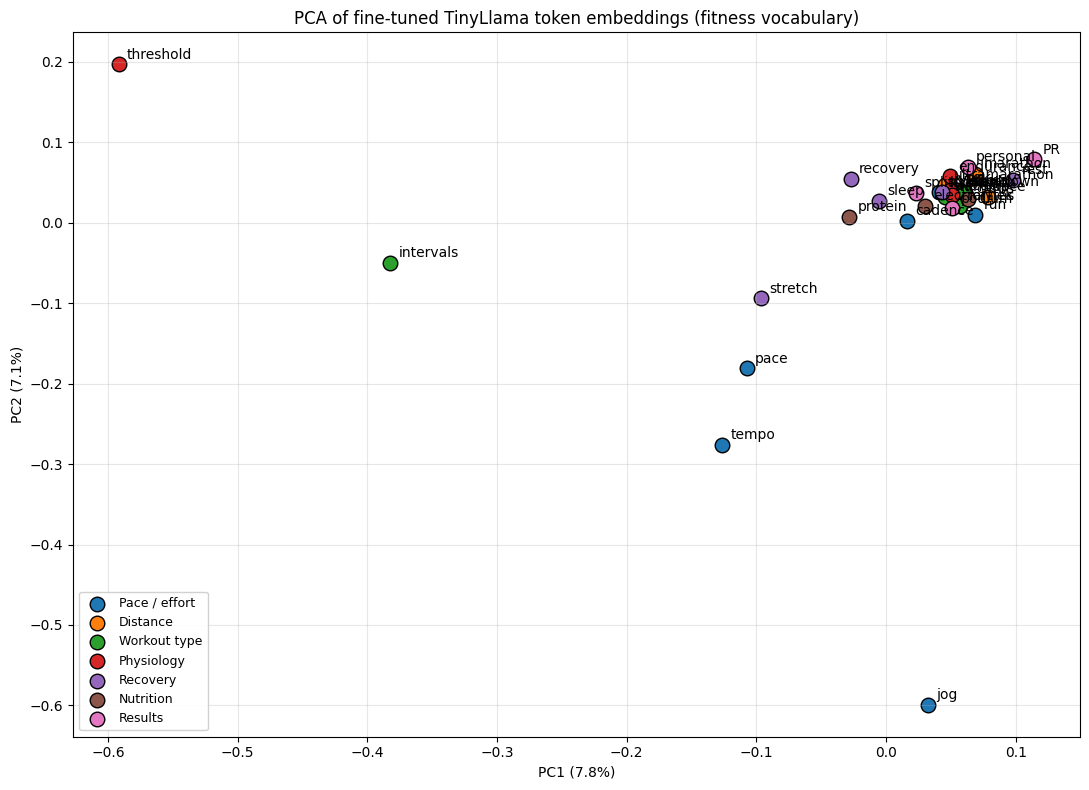

Saved PCA figure to fitness_pca.png


In [14]:
CATEGORIES = {
    "Pace / effort":  ["run", "sprint", "tempo", "jog", "pace", "stride", "cadence"],
    "Distance":       ["marathon", "10K", "5K", "race", "ultramarathon"],
    "Workout type":   ["intervals", "fartlek", "taper", "warmup", "cooldown"],
    "Physiology":     ["VO2max", "lactic", "threshold", "endurance"],
    "Recovery":       ["recovery", "rest", "hydration", "stretch", "sleep"],
    "Nutrition":      ["carbs", "protein", "electrolytes"],
    "Results":        ["splits", "PR", "personal", "podium"],
}
word_to_cat = {w: cat for cat, ws in CATEGORIES.items() for w in ws}

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vectors)
print("Explained variance ratio:", pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.get_cmap("tab10")
for i, cat in enumerate(CATEGORIES):
    mask = np.array([word_to_cat.get(w) == cat for w in FITNESS_WORDS])
    ax.scatter(coords[mask, 0], coords[mask, 1], s=110, color=cmap(i), label=cat, edgecolor="k")

for i, w in enumerate(FITNESS_WORDS):
    ax.annotate(w, (coords[i, 0], coords[i, 1]),
                fontsize=10, xytext=(6, 4), textcoords="offset points")

ax.set_title("PCA of fine-tuned TinyLlama token embeddings (fitness vocabulary)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(loc="best", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fitness_pca.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved PCA figure to fitness_pca.png")

## Summary

- **Task:** domain-specific conversational Q&A / instruction following.
- **Domain & Dataset:** fitness / training / nutrition, `its-myrto/fitness-question-answers` (700 train / 80 eval / 80 test samples drawn from a curated 965-row fitness Q&A corpus).
- **Model:** `TinyLlama/TinyLlama-1.1B-Chat-v1.0` loaded in **4-bit NF4** (~0.8 GB VRAM).
- **Configuration:** QLoRA — LoRA `r=16`, `alpha=32`, target `q_proj` & `v_proj`; `paged_adamw_8bit`; batch 1 × grad-accum 8; `bf16`; gradient checkpointing.
- **Evaluation:**
  - Perplexity on the held-out test split, base vs fine-tuned.
  - Qualitative side-by-side generation on five realistic fitness questions.
- **Bonus:** PCA projection of fine-tuned token embeddings for 30+ fitness words. Words from the same category (paces, distances, recovery, nutrition, …) cluster together, indicating that the model's representations encode the structure of the fitness domain.